In [130]:
#membaca dataset dari file csv
import pandas as pd 
df = pd.read_csv("/home/haikal/Water-Quality-Clasification/data/waterQuality1.csv")
df.head() #melihat 5 data pertama pada dataset

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [131]:
#menampilkan statistik deskriptif dari dataset
df.describe()

,aluminium,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,viruses,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium
count,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000
mean,0.666158,0.161445,1.567715,0.042806,2.176831,0.247226,0.805857,0.771565,0.319665,0.328583,0.099450,9.818822,1.329961,0.005194,16.460299,2.920548,0.049685,0.147781,0.044673
std,1.265145,0.252590,1.216091,0.036049,2.567027,0.270640,0.653539,0.435373,0.329485,0.378096,0.058172,5.541331,0.573219,0.002967,17.687474,2.323009,0.028770,0.143551,0.026904
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.040000,0.030000,0.560000,0.008000,0.100000,0.050000,0.090000,0.405000,0.000000,0.002000,0.048000,5.000000,1.000000,0.003000,2.170000,0.820000,0.020000,0.040000,0.020000
50%,0.070000,0.050000,1.190000,0.040000,0.530000,0.090000,0.750000,0.770000,0.220000,0.008000,0.102000,9.930000,1.420000,0.005000,7.740000,2.410000,0.050000,0.080000,0.050000
75%,0.280000,0.100000,2.480000,0.070000,4.240000,0.440000,1.390000,1.160000,0.610000,0.700000,0.151000,14.610000,1.760000,0.008000,29.480000,4.670000,0.070000,0.240000,0.070000
max,5.050000,1.050000,4.940000,0.130000,8.680000,0.900000,2.000000,1.500000,1.000000,1.000000,0.200000,19.830000,2.930000,0.010000,60.010000,7.990000,0.100000,0.500000,0.090000


In [132]:
import numpy as np
#memeriksa missing value pada dataset
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [133]:
df.info() #menampilkan tipe data dari setiap kolom pada dataset

<class 'pandas.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   str    
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uranium      7999

In [134]:
for col in df.columns:
    # Cek apakah ada nilai dalam kolom yang tipenya string
    punya_string = df[col].apply(lambda x: isinstance(x, str)).any()
    if punya_string:
        print(f"⚠️ Kolom '{col}' mengandung data teks!")

⚠️ Kolom 'ammonia' mengandung data teks!
⚠️ Kolom 'is_safe' mengandung data teks!


In [135]:
for col in df.columns:
    texts = df[df[col].apply(lambda x: isinstance(x, str))][col].unique()
    if len(texts) > 0:
        print(f"Kolom [{col}] punya teks: {texts}")
        # Menampilkan index barisnya
        idx = df[df[col].apply(lambda x: isinstance(x, str))].index.tolist()
        print(f"Ada di baris index: {idx[:10]} ... (total {len(idx)} baris)\n")

Kolom [ammonia] punya teks: <StringArray>
[ '9.08', '21.16', '14.02', '11.33', '24.33', '14.47',   '5.6', '19.87',
 '24.58', '16.76',
 ...
  '8.23',  '2.42', '14.58',  '1.55',  '6.84', '15.35',  '6.87',  '2.78',
 '27.12',    '10']
Length: 2564, dtype: str
Ada di baris index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... (total 7999 baris)

Kolom [is_safe] punya teks: <StringArray>
['1', '0', '#NUM!']
Length: 3, dtype: str
Ada di baris index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... (total 7999 baris)



dari hasil di atas di dapatkan bahwa tidak terdapat missing value pada dataset yang saya gunakan. namun terdapat beberapa data yang tipernya berbeda yang seharusnya integer jadi string walaupun ketika saya menlakukan pengecekan tipe data tipenya itu float dan integet namun ketika saya ingin mengganti nilai outler tidak bisa karena terdapat tipe data str. jadi sayamelakukan pengecekan tipe data lagi dan terdapat beberapa baris data yang mempunyai tipe string dan #NUM!

In [136]:
# Menghapus baris yang mengandung '#NUM!' di kolom tertentu
df = df[df['ammonia'] != '#NUM!']
df = df[df['is_safe'] != '#NUM!']

# Opsional: Reset index agar urutan barisnya rapi kembali (0, 1, 2...)
df = df.reset_index(drop=True)
df['is_safe'] = pd.to_numeric(df['is_safe'], errors='coerce')
df['ammonia'] = pd.to_numeric(df['ammonia'], errors='coerce')

#melakukan pengecekan lagi 
for col in df.columns:
    texts = df[df[col].apply(lambda x: isinstance(x, str))][col].unique()
    if len(texts) > 0:
        print(f"Kolom [{col}] punya teks: {texts}")
        # Menampilkan index barisnya
        idx = df[df[col].apply(lambda x: isinstance(x, str))].index.tolist()
        print(f"Ada di baris index: {idx[:10]} ... (total {len(idx)} baris)\n")


sudah tidak terdapat fitur yang memiliki tipe str dan #NUM!

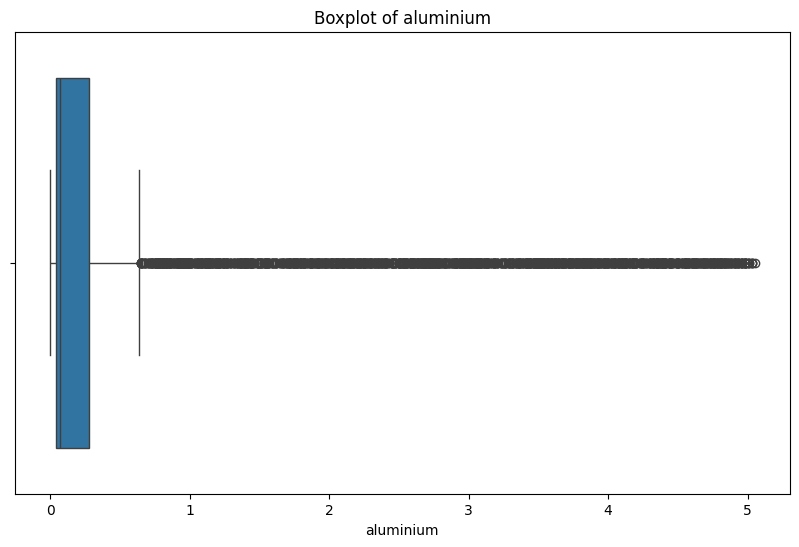

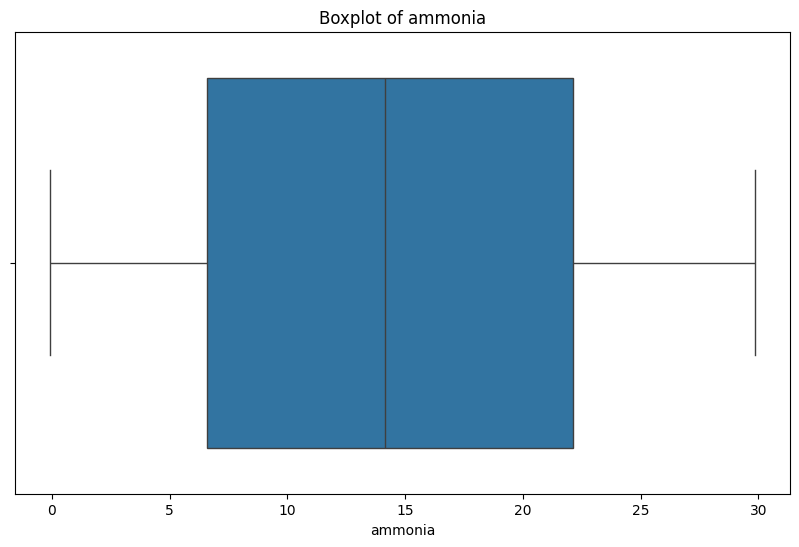

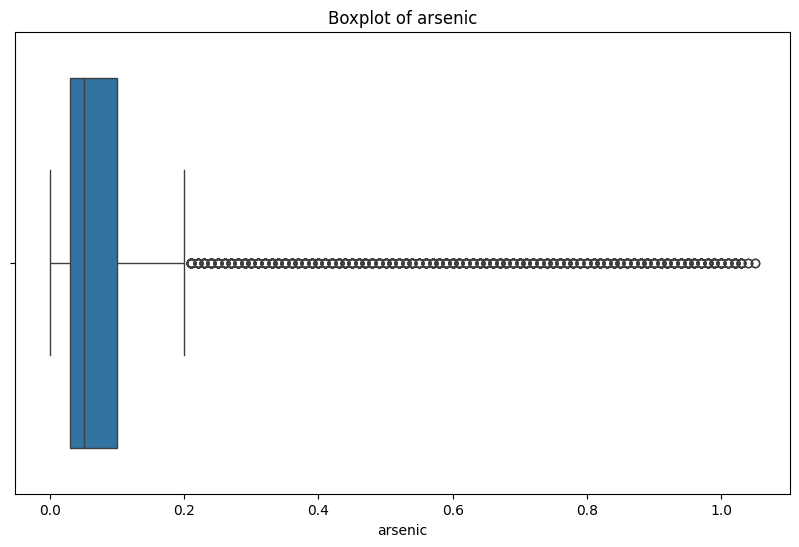

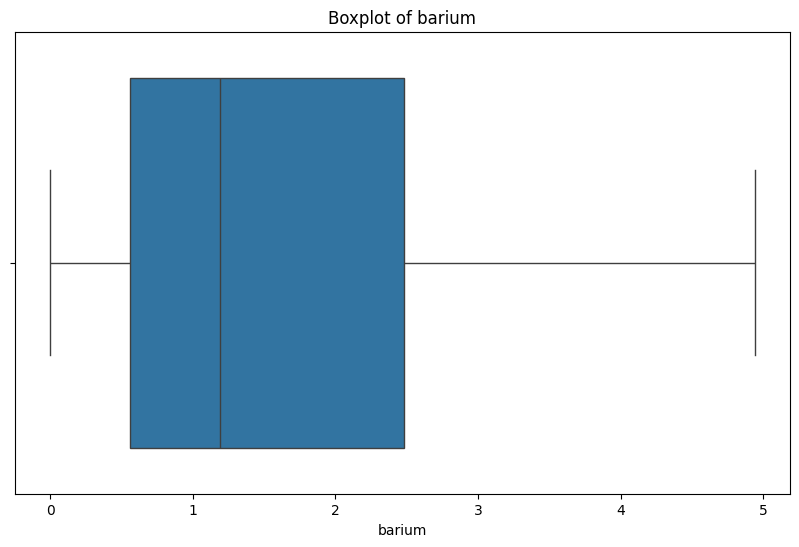

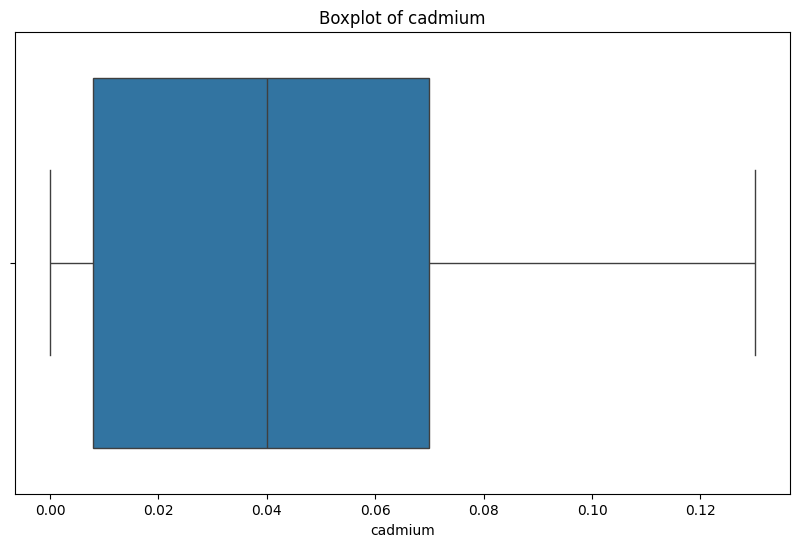

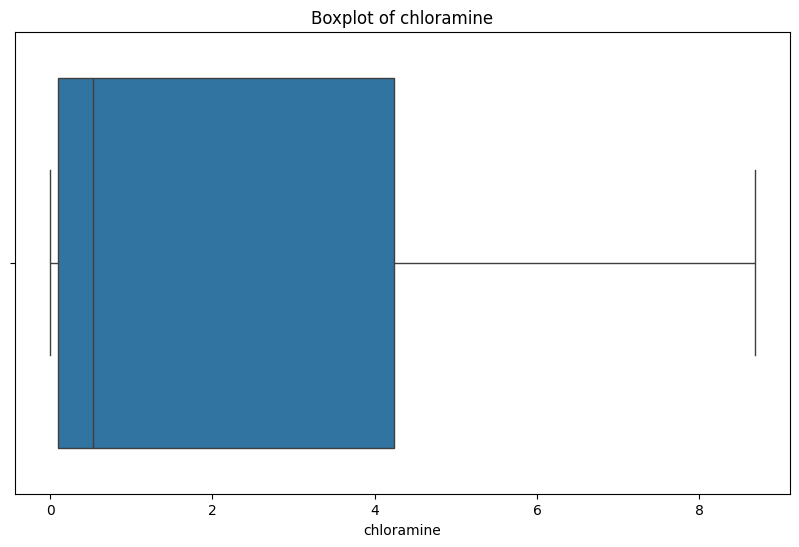

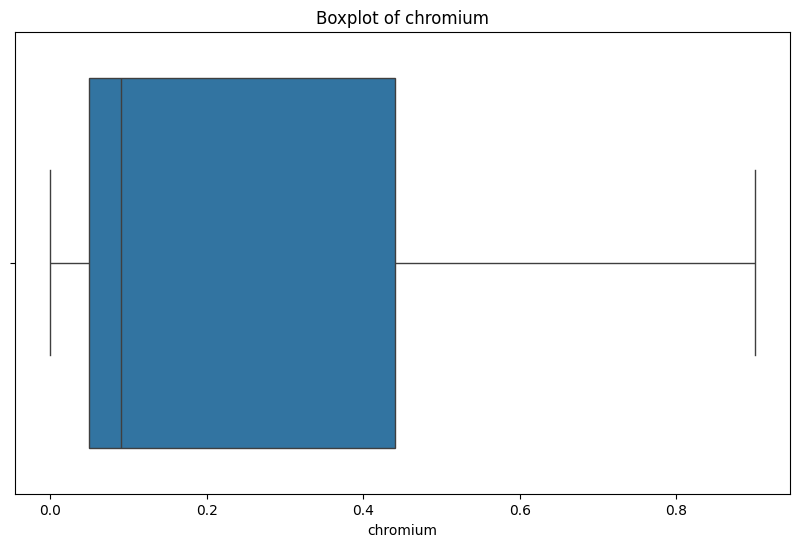

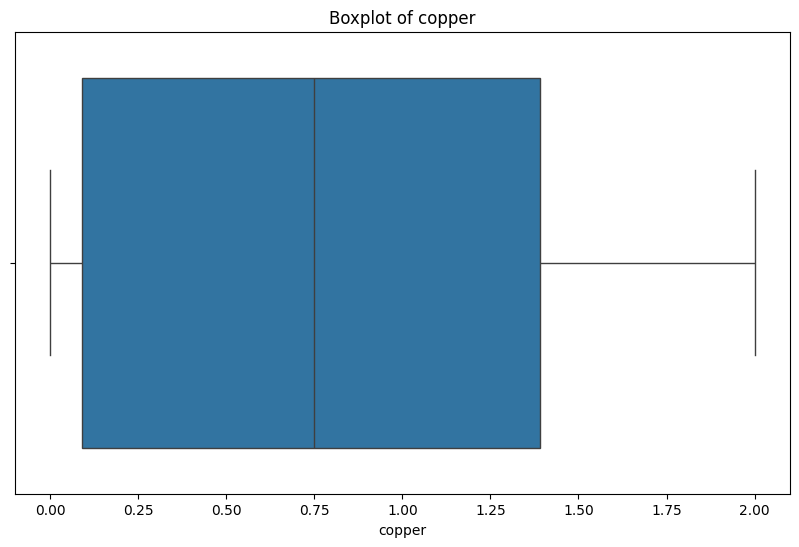

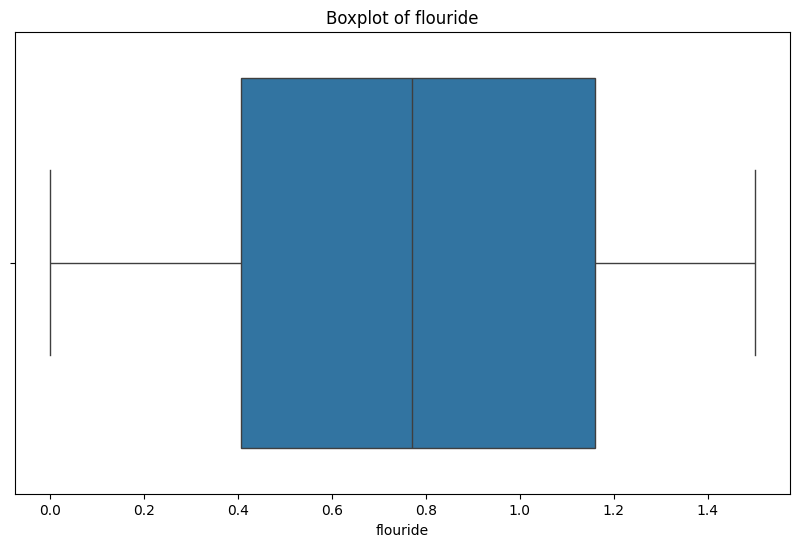

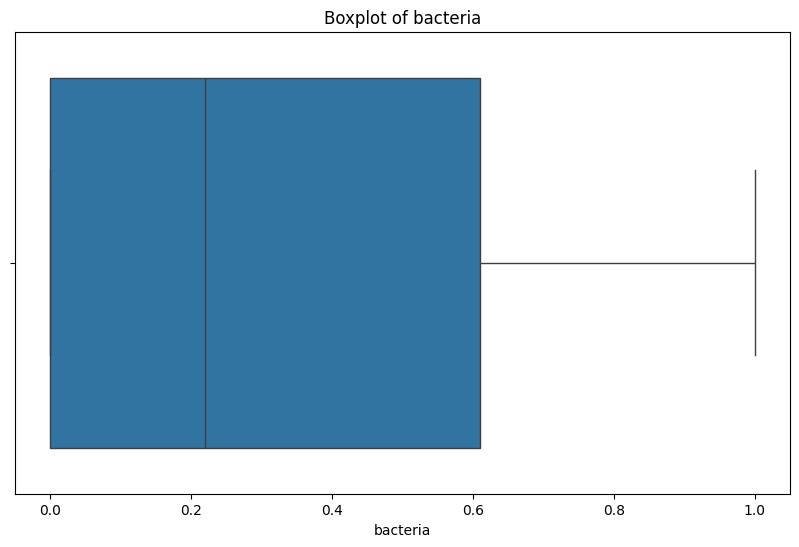

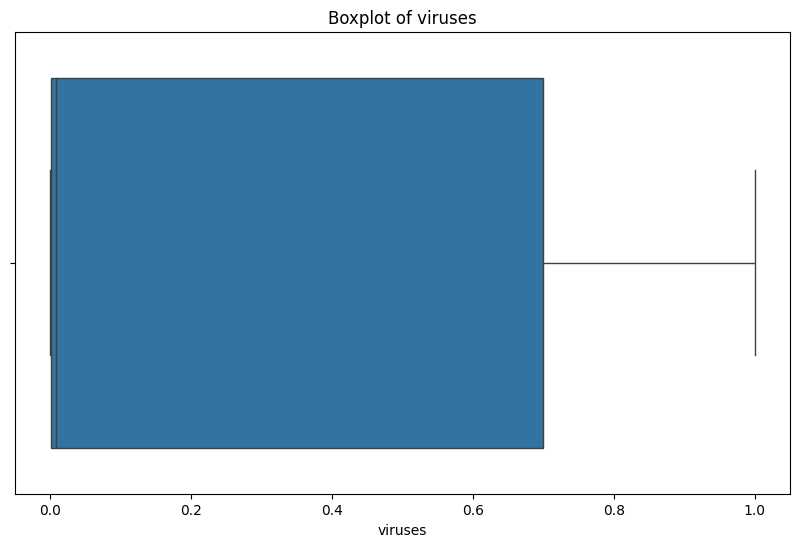

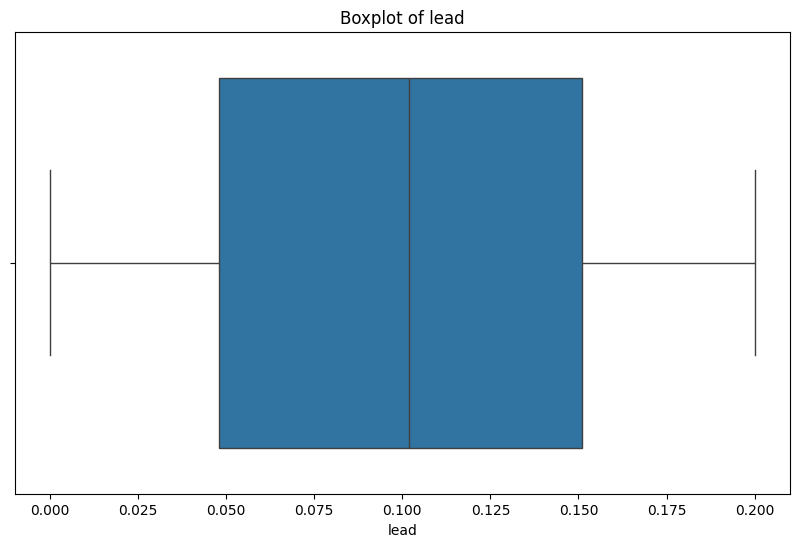

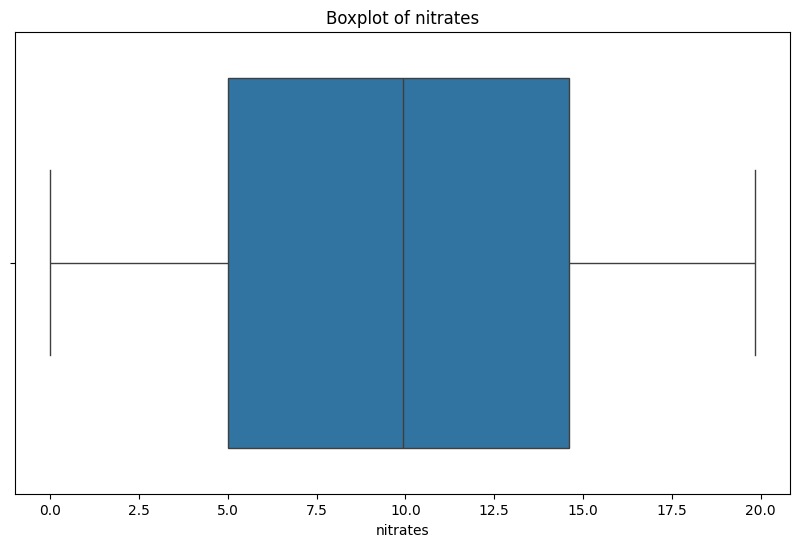

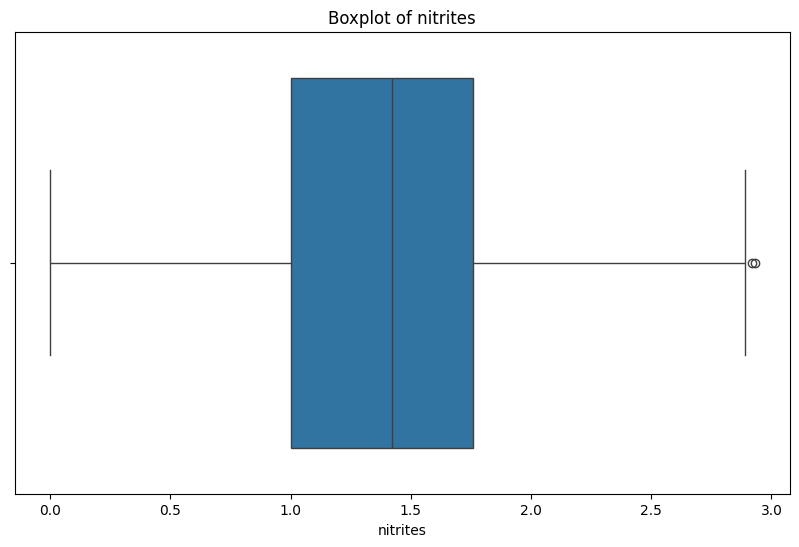

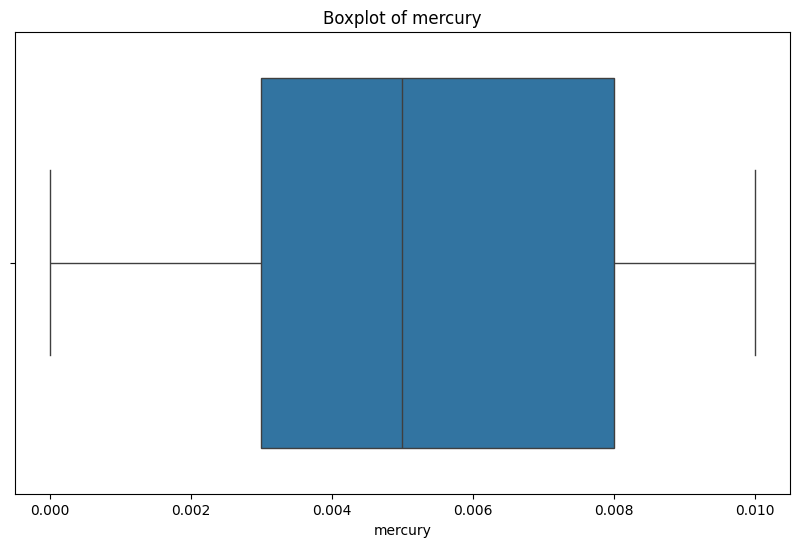

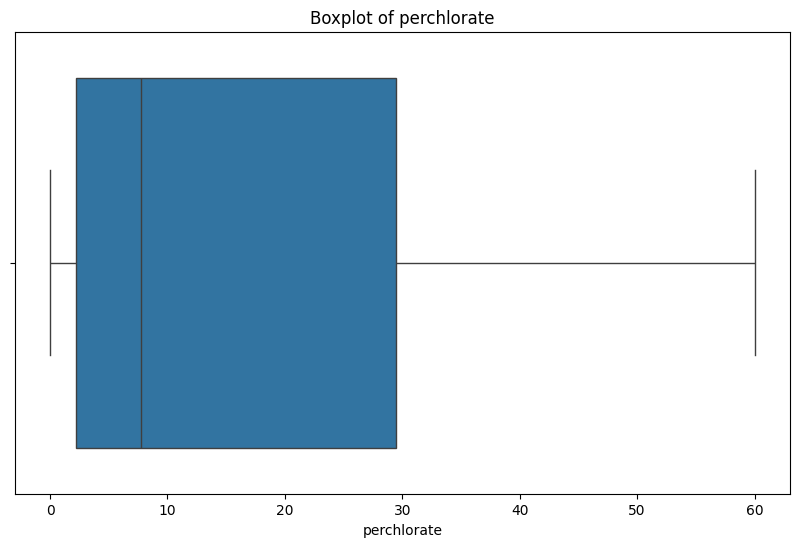

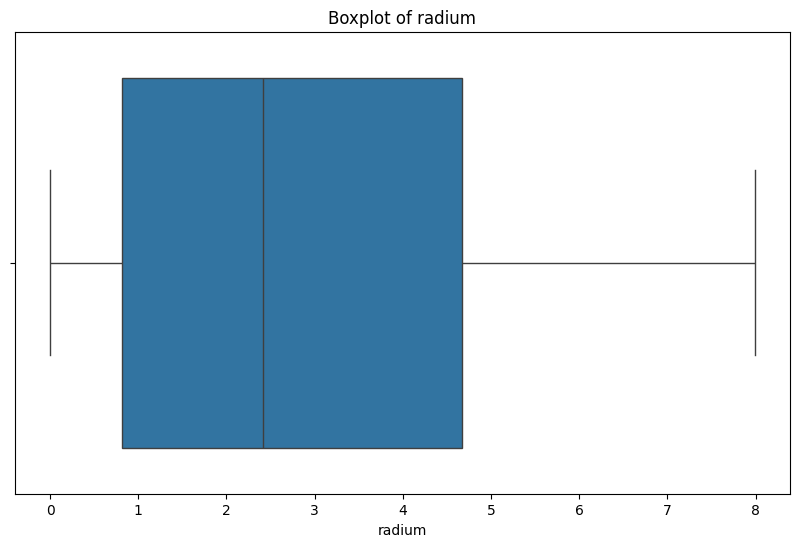

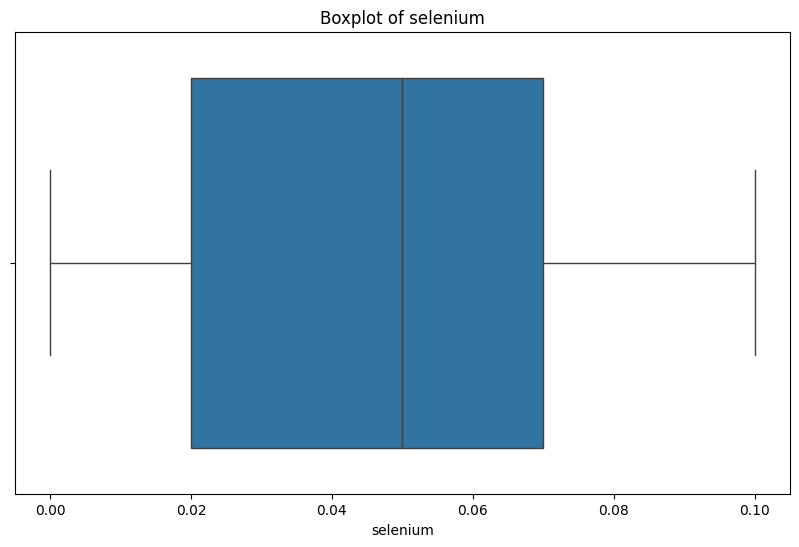

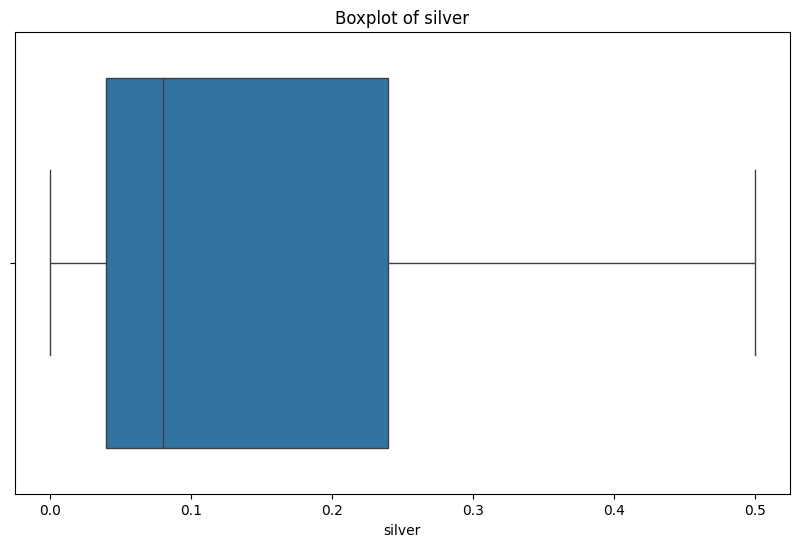

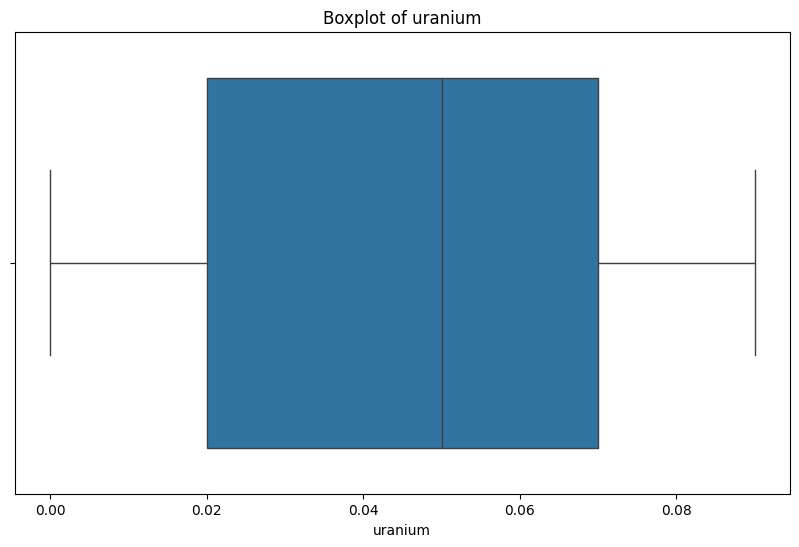

In [137]:
#melihat nilai apakah terdapat nilai yang outler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
#menampilkan boxplot untuk setiap fitur pada dataset
features = df.columns.drop('is_safe') #menghapus kolom target dari fitur yang akan diplot
for column in features:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

In [138]:
#mengahpus nilai outlier dengan metode IQR
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# 1. Mengganti nilai outlier dengan batas bawah dan atas
df[features] = df[features].clip(lower=lower_limit, upper=upper_limit, axis=1)

# 2. Karena tidak ada baris yang dihapus, df tetap utuh (numerik & kategorikal)
print("Jumlah baris tetap:", df.shape[0])

Jumlah baris tetap: 7996


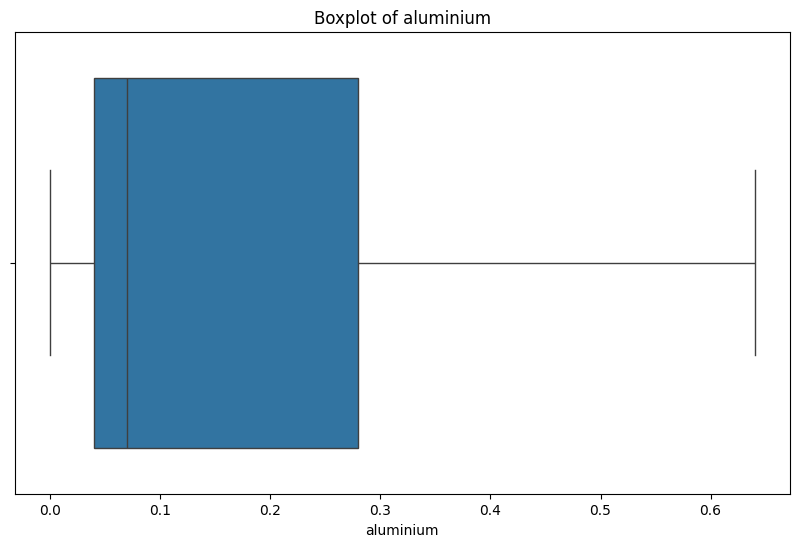

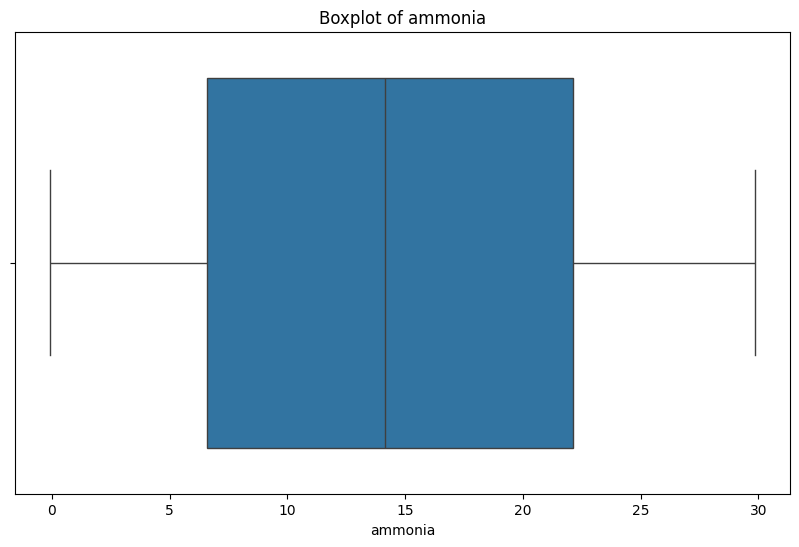

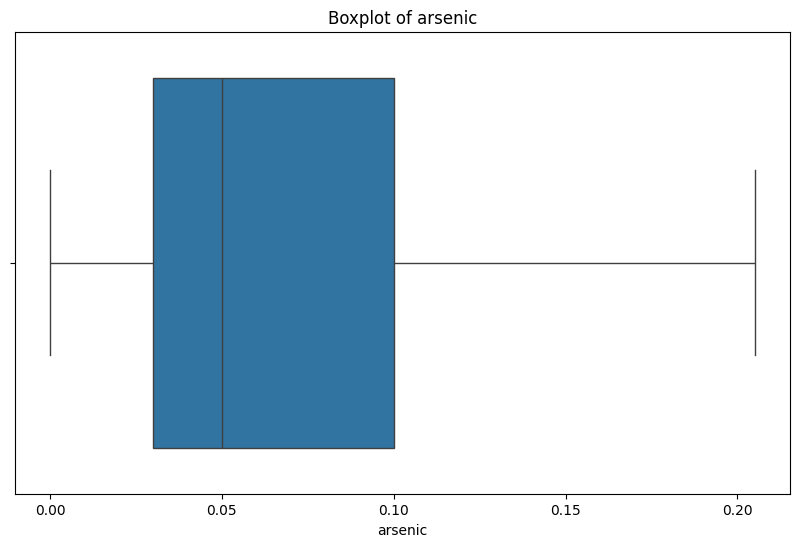

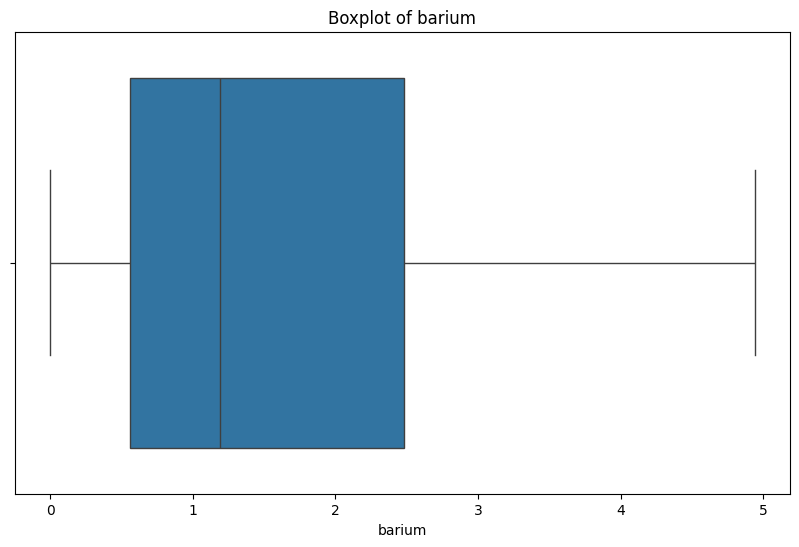

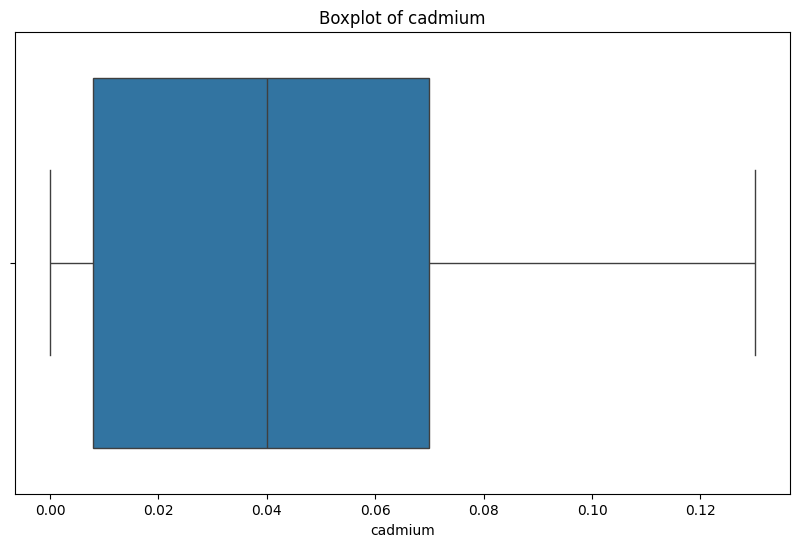

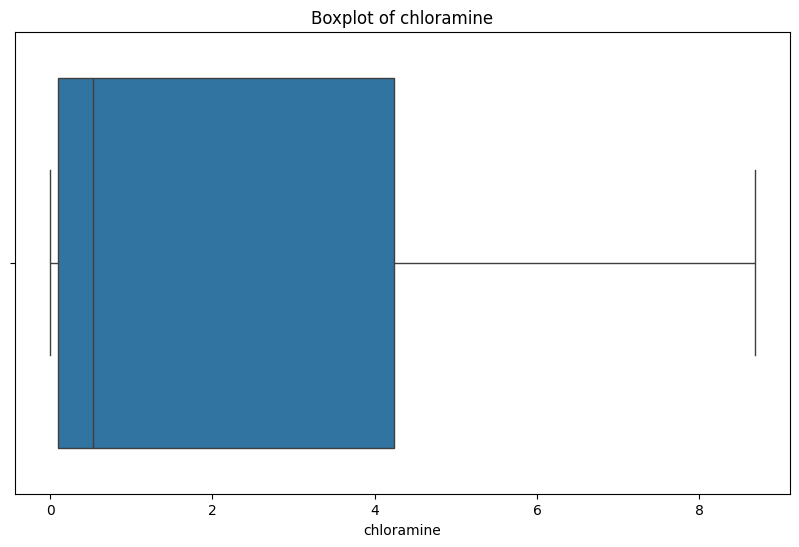

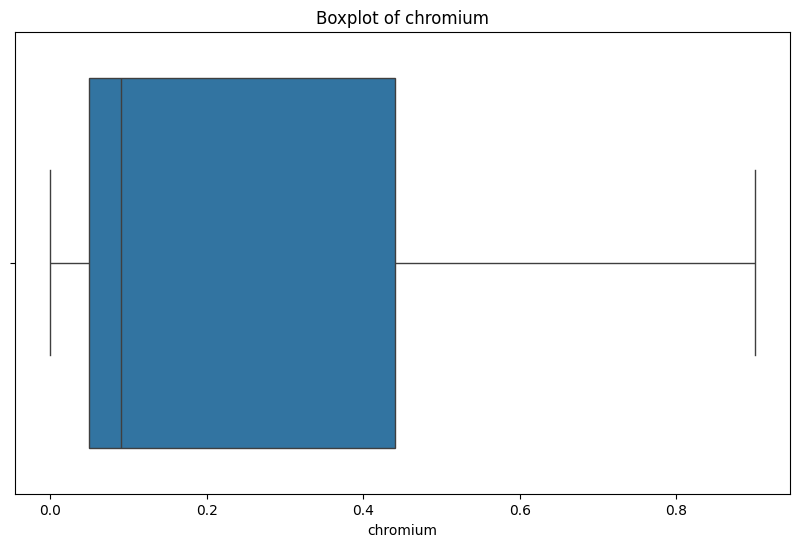

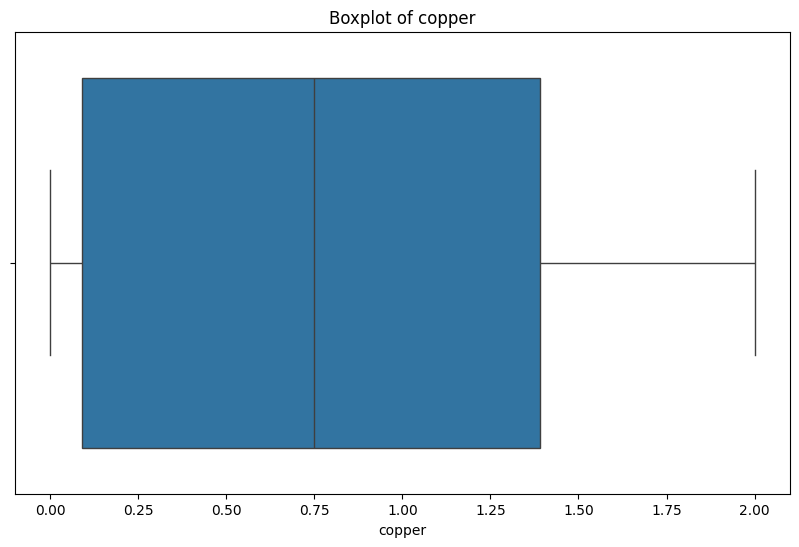

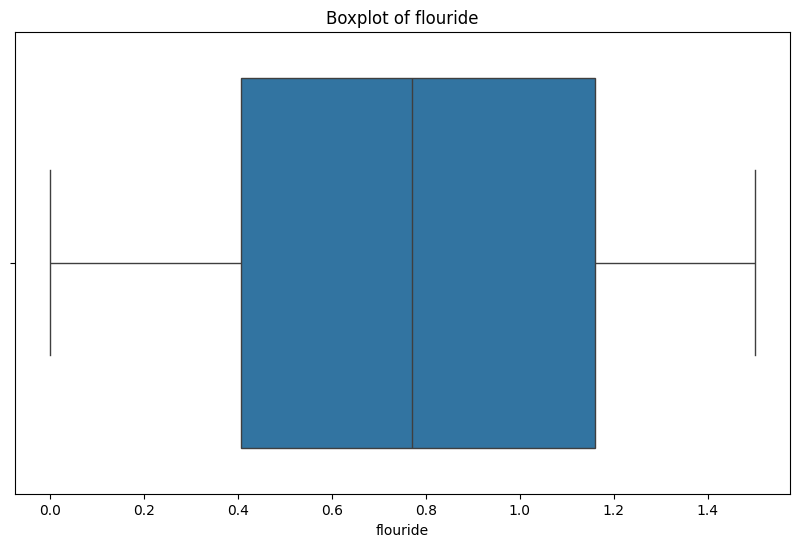

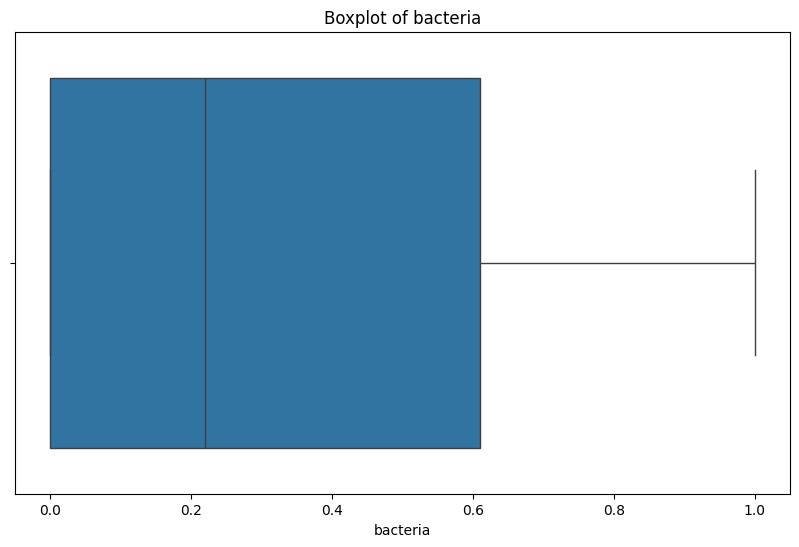

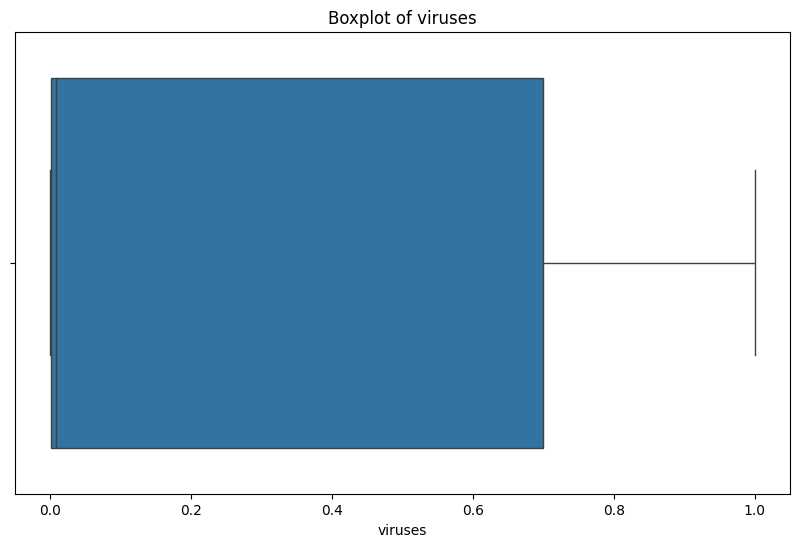

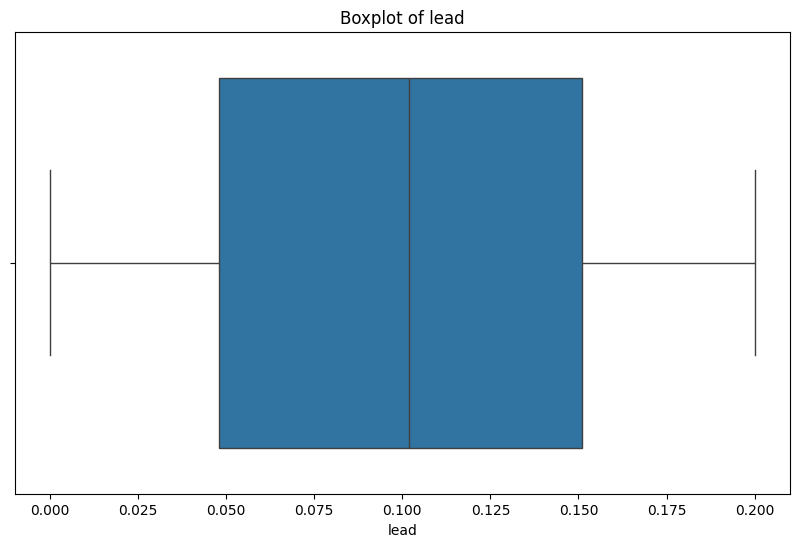

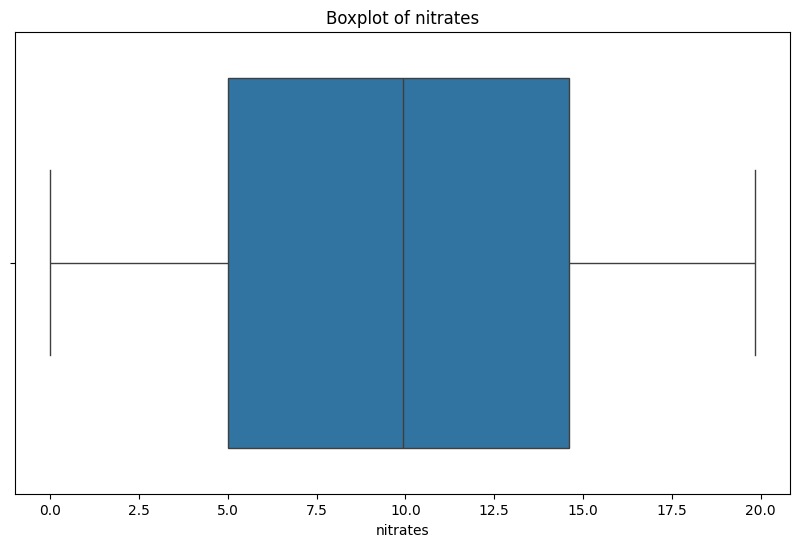

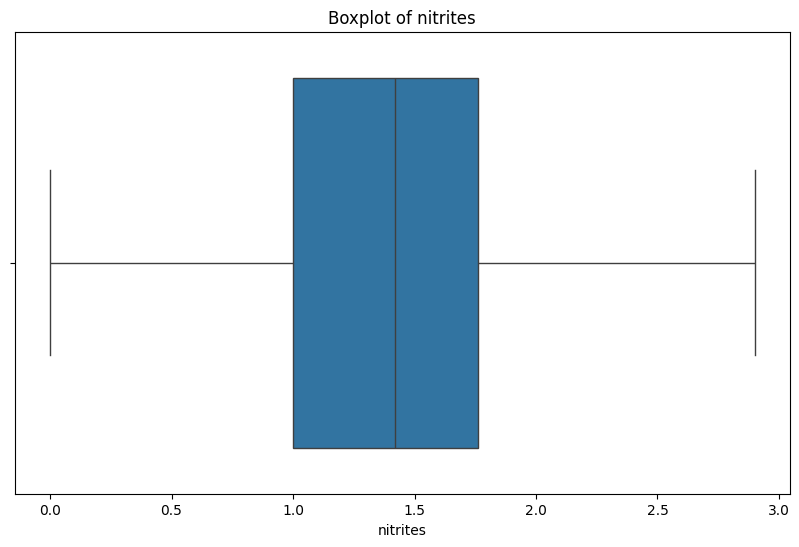

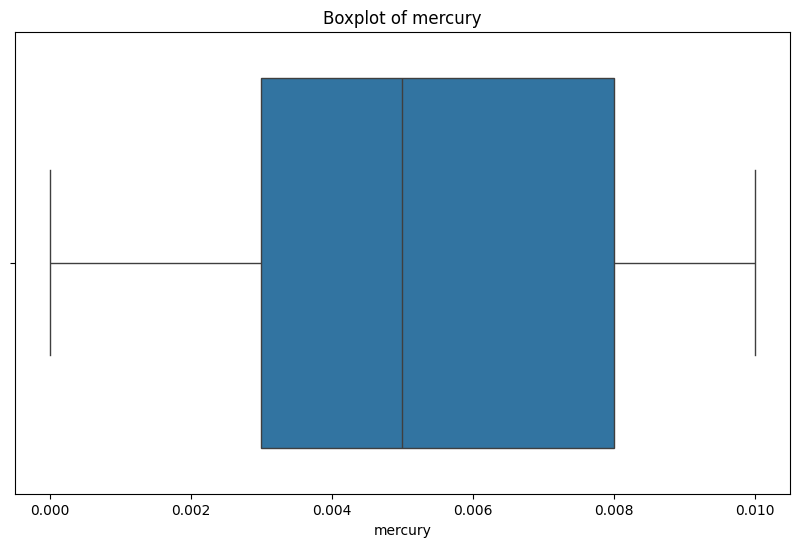

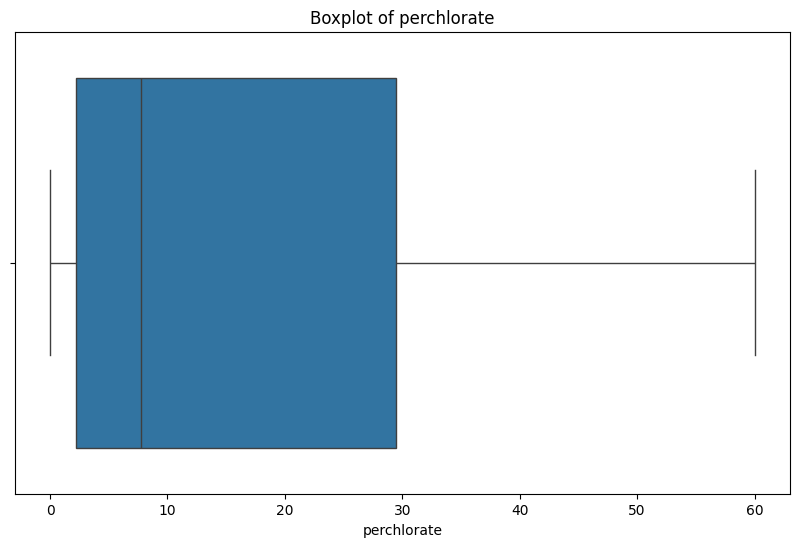

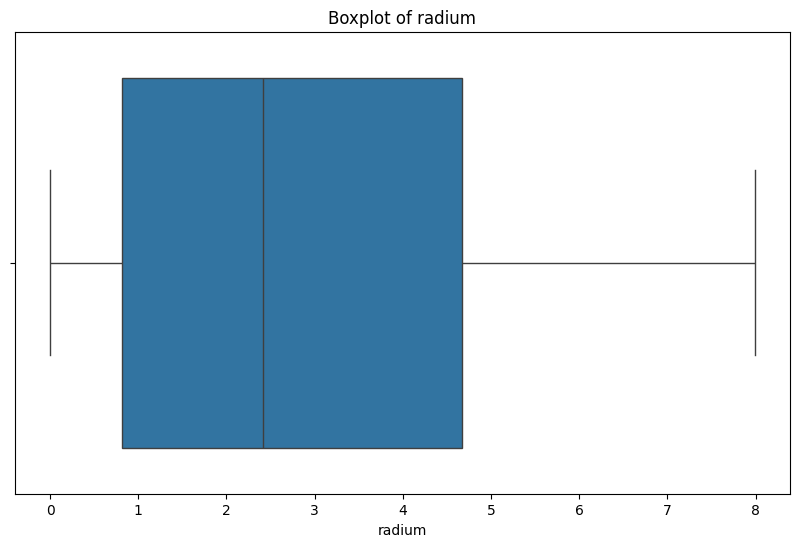

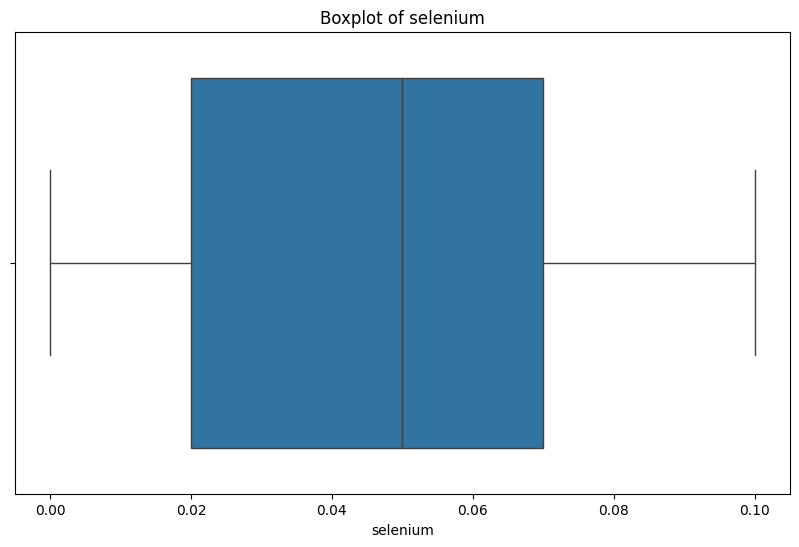

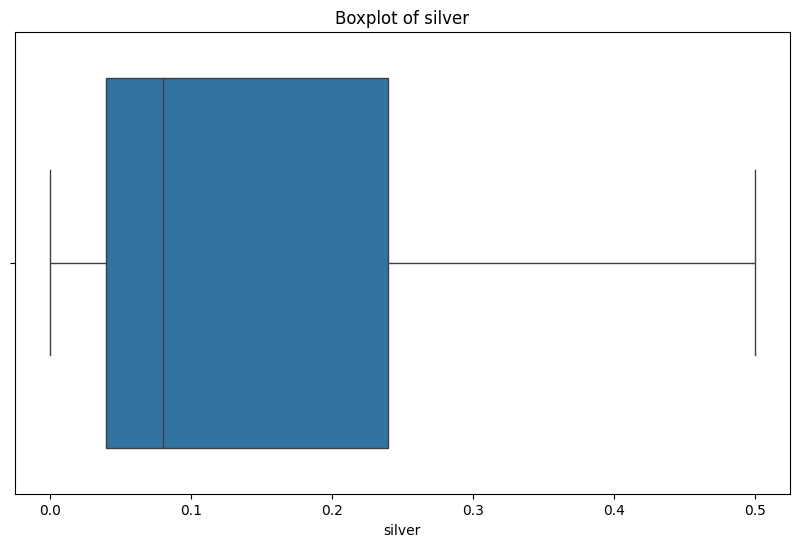

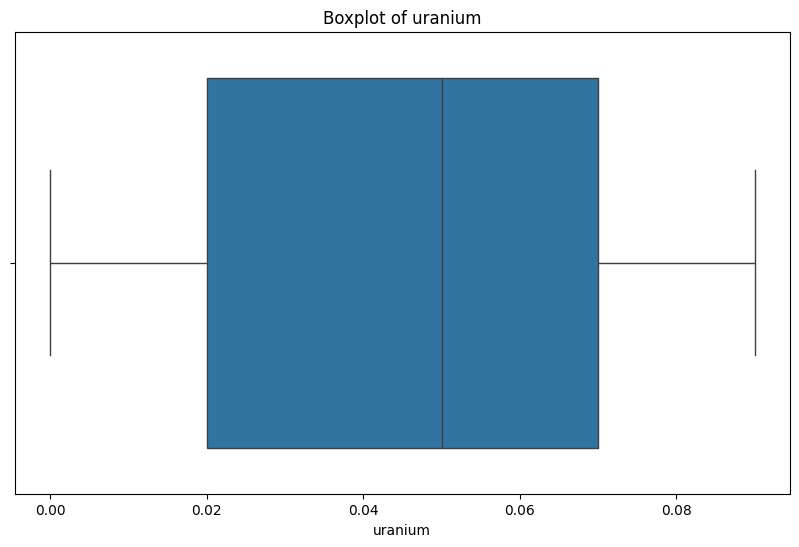

In [139]:
#melihat nilai setelah menghapus outlier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
#menampilkan boxplot untuk setiap fitur pada dataset
for column in features:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

In [140]:
# Mengidentifikasi baris duplikat
duplicates = df.duplicated()
 
print("Baris duplikat:")
print(df[duplicates])

Baris duplikat:
Empty DataFrame
Columns: [aluminium, ammonia, arsenic, barium, cadmium, chloramine, chromium, copper, flouride, bacteria, viruses, lead, nitrates, nitrites, mercury, perchlorate, radium, selenium, silver, uranium, is_safe]
Index: []

[0 rows x 21 columns]


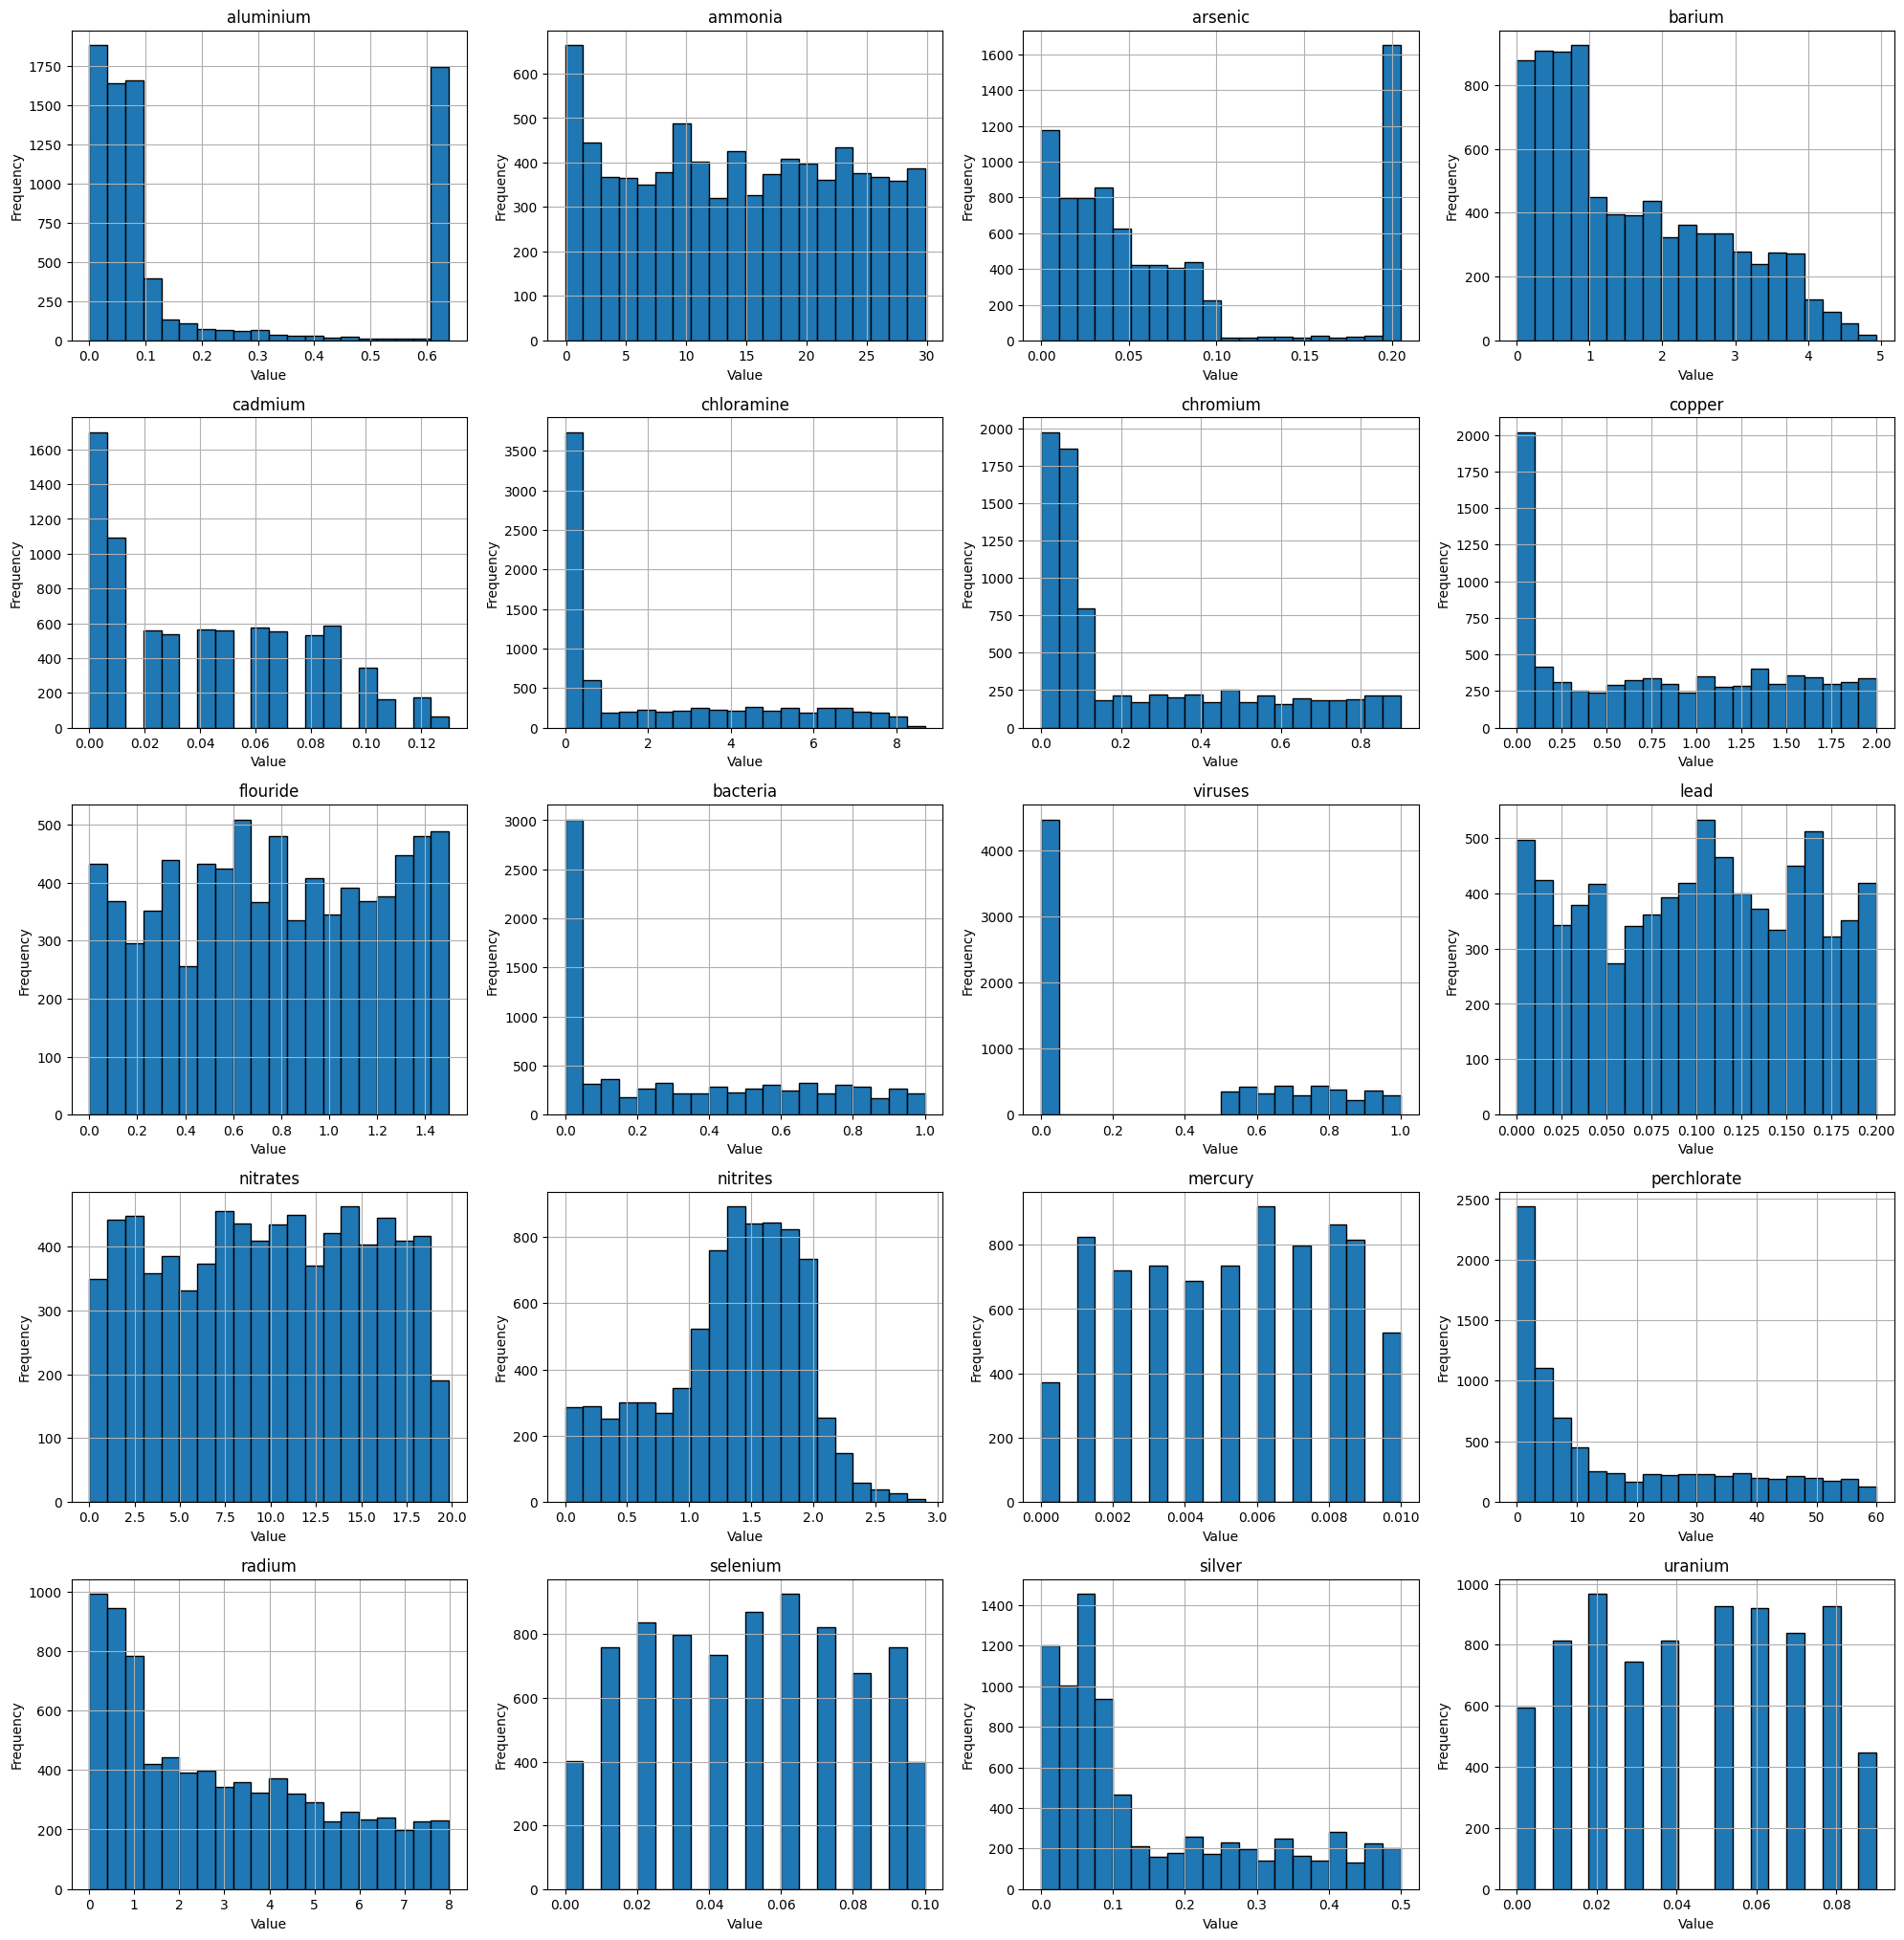

In [141]:
#melihat distribusi kelas pada target variabel
# Menghitung jumlah variabel
num_vars = df.shape[1]
 
# Menentukan jumlah baris dan kolom untuk grid subplot
n_cols = 4  # Jumlah kolom yang diinginkan
n_rows = -(-num_vars // n_cols)  # Ceiling division untuk menentukan jumlah baris
 
# Membuat subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
 
# Flatten axes array untuk memudahkan iterasi jika diperlukan
axes = axes.flatten()
 
# Plot setiap variabel
for i, column in enumerate(df.columns[:20]):  # Membatasi hanya pada 20 variabel pertama untuk visualisasi
    df[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
 
# Menghapus subplot yang tidak terpakai (jika ada)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
 
# Menyesuaikan layout agar lebih rapi
plt.tight_layout()
plt.show()

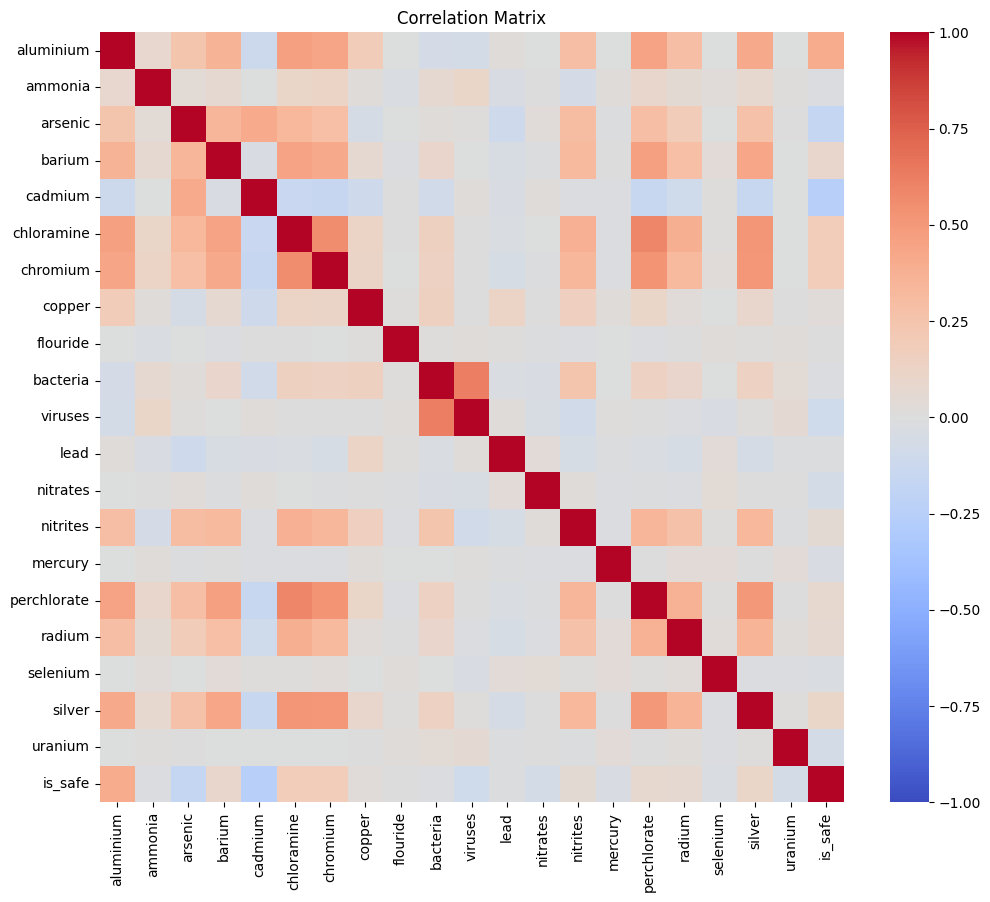

In [142]:
#melihat matriks korelasi antar fitur
# Visualisasi korelasi antar variabel numerik dengan menggunakan matriks korelasi
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
 
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

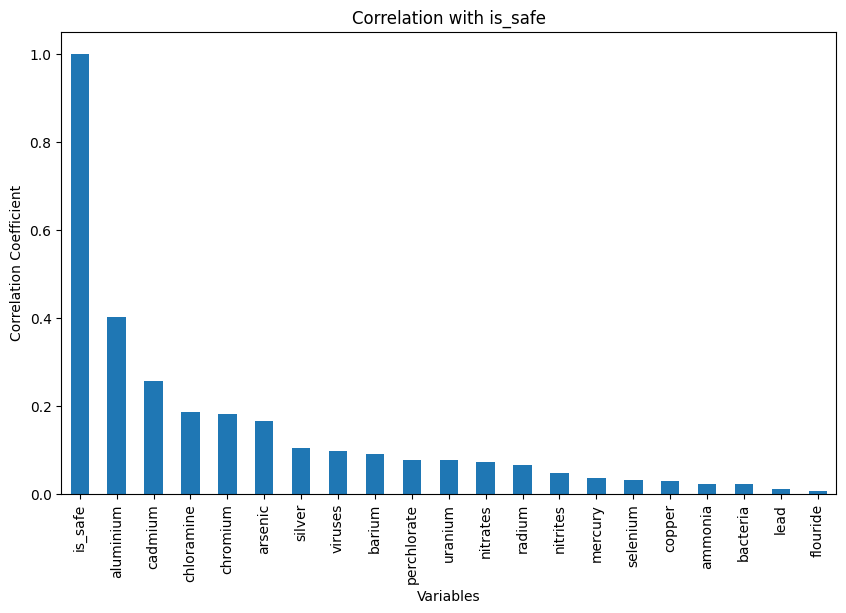

In [143]:
#membandingkan variabel target dengan variabel lainnya
# Menghitung korelasi antara variabel target dan semua variabel lainnya
target_corr = df.corr()['is_safe'] #masukkan nama variabel target nya di sini 
 
# (Opsional) Mengurutkan hasil korelasi berdasarkan korelasi
target_corr_sorted = target_corr.abs().sort_values(ascending=False).head(21)  # Menampilkan 20 variabel dengan korelasi tertinggi (beserta target)
 
plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with is_safe')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

dari hasil perbandingan dengan target, 5 fitur pertama yang berpengaruh langsung terdahap kualitas air bisa di minum atau tidak yaitu aluminium, cadmium, chloramine,chromium dan arsenic

In [144]:
#melakukan spliting data
# Memisahkan fitur (X) dan target (y)
X = df.drop(columns=['is_safe'])
y = df['is_safe']


In [145]:
from sklearn.model_selection import train_test_split
# membagi dataset menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [146]:
#melakukan standarisai data dengan menggunakan StandardScaler untuk fitur numerik dan OneHotEncoder untuk fitur kategorikal
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler


 
# 1. Pastikan fitur hanya berisi kolom yang ADA di x_train (dan bukan target)
target_column = 'is_safe' # Ganti dengan nama targetmu jika berbeda

clean_df = [col for col in df if col in X_train.columns and col != target_column]


# 2. Definisikan preprocessor (Langsung masukkan list-nya saja)

preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), features) # clean_numeric adalah list nama kolom fiturmu
    #melakukan normalisasi karena algoritma yang menghitung jarak 
])

# 3. Eksekusi
# X_train_scaled akan menjadi NumPy Array
X_train_scaled = preprocessor.fit_transform(X_train) 
X_test_scaled = preprocessor.transform(X_test) 




In [147]:
#melakukan pelatihan model 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
# Bagian 1: Pelatihan Model
# Definisikan setiap klasifikasi secara terpisah
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)
 
print("Model training selesai.")

Model training selesai.


In [148]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai kamus
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # ravel() memecah matriks 2x2 menjadi 4 nilai
    tn, fp, fn, tp = cm.ravel() 
    
    results = {
        'Confusion Matrix': cm,
        'True Positive (TP)': tp,
        'False Positive (FP)': fp,
        'False Negative (FN)': fn,
        'True Negative (TN)': tn,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    }
    return results
 
# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test)
}
 
# Buat DataFrame untuk meringkas hasil (langsung menggunakan list comprehension agar lebih rapi)
rows = [
    {
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    }
    for model_name, metrics in results.items()
]
 
# Konversi ke DataFrame
summary_df = pd.DataFrame(rows)
 
# Tampilkan DataFrame
print(summary_df)

                          Model  Accuracy  Precision    Recall  F1-Score
0     K-Nearest Neighbors (KNN)  0.873125   0.240000  0.067797  0.105727
1            Decision Tree (DT)  0.956250   0.780105  0.841808  0.809783
2            Random Forest (RF)  0.960625   0.931818  0.694915  0.796117
3  Support Vector Machine (SVM)  0.889375   0.000000  0.000000  0.000000
4              Naive Bayes (NB)  0.875625   0.456349  0.649718  0.536131


Berdasarkan hasil pengujian terhadap lima algoritma Machine Learning, Decision Tree (DT) terpilih sebagai model paling optimal untuk mengklasifikasikan kualitas air pada dataset ini. Model ini unggul dengan nilai Accuracy mencapai 96% dan F1-Score sebesar 0.82, yang menunjukkan keseimbangan performa yang sangat baik antara presisi dan sensitivitas. Hal yang paling krusial dalam konteks keamanan air adalah nilai Recall-nya yang mencapai 0.85, yang berarti Decision Tree paling efektif dalam mendeteksi air yang berbahaya dibandingkan model lainnya. Sementara itu, Random Forest menempati posisi kedua dengan tingkat presisi yang sangat tinggi namun kurang sensitif dalam menangkap data kelas positif, sedangkan model seperti SVM dan KNN gagal memberikan hasil yang berguna karena tidak mampu menangani ketimpangan jumlah data (imbalanced data) pada dataset ini.

In [ ]:
import joblib

#meyimpan model desision tree
joblib.dump(dt, 'model_dt_final.joblib')



['model_dt_final.joblib']